In [2]:
suppressPackageStartupMessages({
    library(Seurat)
    library(Signac)
    library(Matrix)
    library(dplyr)
    library(SummarizedExperiment)
    library(ggplot2)
    library(tibble)
    library(rstatix)
    library(reshape2)
    library(tidyr)
    library(scales)
    '%ni%' <- Negate('%in%')
    source("2_HelperFunction.R")
    source("../../global/quantifyMMB.R")
})    

Warning message in ifelse(SIFT == "-", NA, as.numeric(sub(".*\\(([^)]+)\\)", "\\1", :
“NAs introduced by coercion”
Warning message in ifelse(PolyPhen == "-", NA, as.numeric(sub(".*\\(([^)]+)\\)", :
“NAs introduced by coercion”


In [3]:
cols <- c(
  "CTRL_Glu"    = "#BBD6FF",
  "CTRL_Gal_1D" = "#2780FF",
  "CTRL_Gal_3D" = "#0040A8",
  "KI36_Glu"    = "#F0BBFF",
  "KI36_Gal_1D" = "#960096",
  "KI36_Gal_3D" = "#5A0050",
  "Doublet"     = "black", 
  "Negative"    = "grey")

In [4]:
# Load data
Gal <- readRDS("../output/1_preprocessed_HEK_POLG_galactose_seurat.rds")

mmat_CTRL <- readRDS("../output/1_mmat_CTRL_Gal.rds")
mmat_KI36 <- readRDS("../output/1_mmat_KI36_Gal.rds")

cov_CTRL <- readRDS("../output/1_scCoverage.CTRL_Gal.rds")
cov_KI36 <- readRDS("../output/1_scCoverage.KI36_Gal.rds")

In [5]:
# extract barcode
CTRL_GluD3_CB <- WhichCells(Gal, idents = "CTRL_Glu"    )
CTRL_GalD1_CB <- WhichCells(Gal, idents = "CTRL_Gal_1D" )
CTRL_GalD3_CB <- WhichCells(Gal, idents = "CTRL_Gal_3D" )
KI36_GluD3_CB <- WhichCells(Gal, idents = "KI36_Glu"    )
KI36_GalD1_CB <- WhichCells(Gal, idents = "KI36_Gal_1D" )
KI36_GalD3_CB <- WhichCells(Gal, idents = "KI36_Gal_3D" )

CTRL_CB = c(CTRL_GluD3_CB, CTRL_GalD1_CB, CTRL_GalD3_CB)
KI36_CB = c(KI36_GluD3_CB, KI36_GalD1_CB, KI36_GalD3_CB)

In [6]:
mmat_het_CTRL <- mgatk_filter(mmat_CTRL)
mmat_het_KI36 <- mgatk_filter(mmat_KI36)

In [7]:
var.CTRL <- setdiff(rownames(mmat_het_CTRL), rownames(mmat_het_KI36))
var.KI36 <- setdiff(rownames(mmat_het_KI36), rownames(mmat_het_CTRL))

In [8]:
scmtMMB <- rbind(
    quantify_MMB(mmat_het_CTRL[var.CTRL,], cov_CTRL, "CTRL"),
    quantify_MMB_psedobulk(mmat_het_CTRL[var.CTRL,], cov_CTRL, "CTRL"),
    quantify_MMB(mmat_het_KI36[var.KI36,], cov_KI36, "KI36"),
    quantify_MMB_psedobulk(mmat_het_KI36[var.KI36,], cov_KI36, "KI36"))

In [9]:
write.csv(scmtMMB, "../output/2_scmtMMB_POLG_Gal.csv", quote = FALSE, row.names = TRUE)

In [10]:
md_to_append <- scmtMMB %>% select(barcode, symbol, mutation_per_MB, MSS_weighted) %>% filter(grepl("Total|CI|CV|RNA", symbol) & barcode != "pseudobulk") %>% tibble::remove_rownames()%>% 
pivot_wider(names_from = symbol, values_from = c(mutation_per_MB, MSS_weighted)) %>% tibble::column_to_rownames("barcode")

In [11]:
Gal <- AddMetaData(object = Gal, metadata = md_to_append, col.name = colnames(md_to_append))

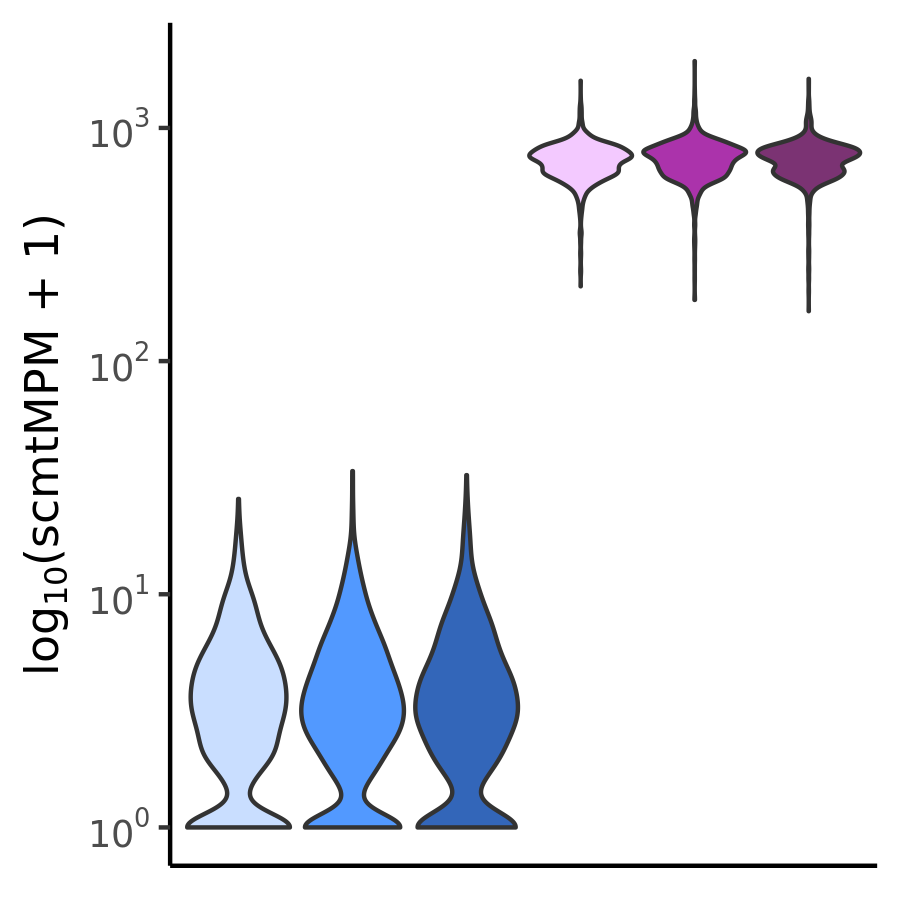

In [15]:
options(repr.plot.width =3, repr.plot.height = 3, repr.plot.res = 300)
(p1 <- Gal@meta.data %>% #filter(grepl("KI36", cellline))%>% 
  ggplot(aes(x = hash.ID, y =  mutation_per_MB_Total + 1)) +
  geom_violin(aes(fill = hash.ID), scale = "width", alpha = 0.8) +
  scale_fill_manual(values = cols) +
  scale_y_log10(breaks = trans_breaks("log10", function(x) 10^x), 
                labels = trans_format("log10", math_format(10^.x)), 
                limit = c(1, NA)) + 
  labs(y = bquote(paste(log[10], "(scmtMPM + 1)"))) + theme_classic() + NoLegend() + xlab(NULL) +
  theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank())) 

 ggsave(plot = p1, "../plot/Gal_scmtMPM.pdf", width =3, height = 3, dpi = 300)

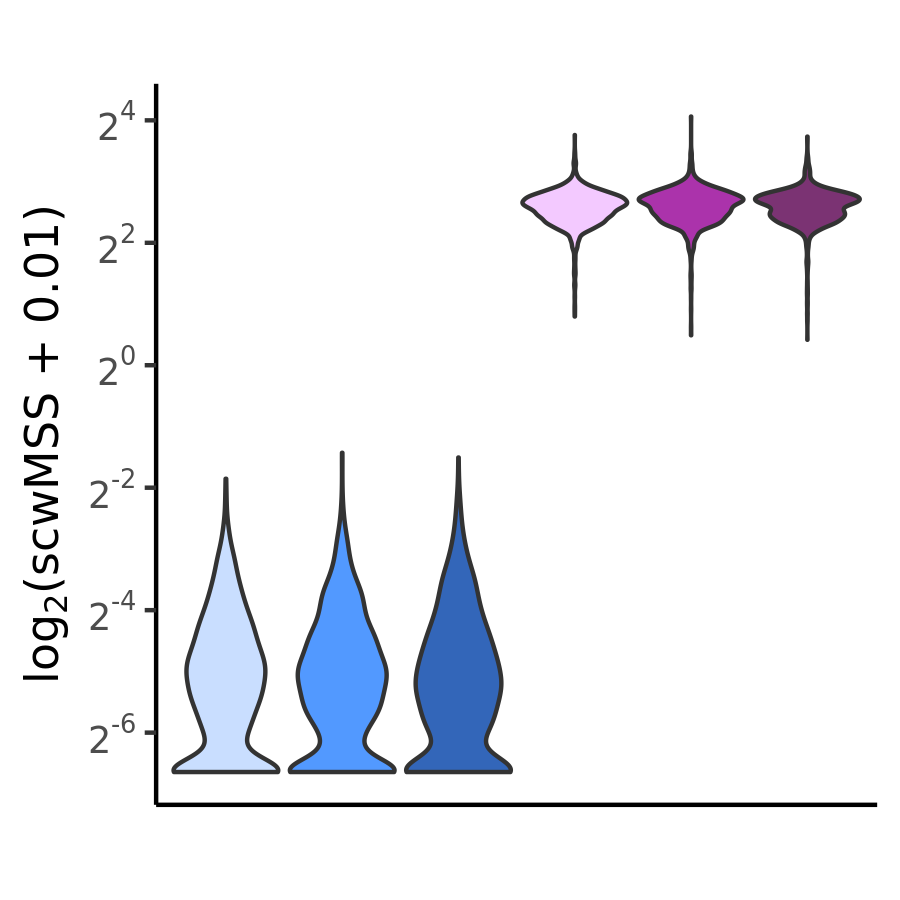

In [14]:
options(repr.plot.width =3, repr.plot.height = 3, repr.plot.res = 300)
(p2 <- Gal@meta.data %>% 
  ggplot(aes(x = hash.ID, y =   MSS_weighted_Total + 0.01)) +
  geom_violin(aes(fill = hash.ID), scale = "width", alpha = 0.8) +
  scale_fill_manual(values = cols) +
  scale_y_continuous(trans = log2_trans(), 
                     breaks = trans_breaks("log2", function(x) 2^x), 
                     labels = trans_format("log2", math_format(2^.x))) + 
  labs(y = bquote(paste(log[2], "(scwMSS + 0.01)"))) +
                theme_classic() + NoLegend() + xlab(NULL) +
  theme(aspect.ratio=1/1, axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank()))
 ggsave(plot = p2, "../plot/Gal_scwMSS.pdf", width =3, height = 3, dpi = 300)

In [14]:
Gal_KI36 <- subset(Gal, cellline == "KI36")

In [15]:
Gal_KI36 <- AddMetaData(object = Gal_KI36,metadata = as.data.frame(Gal_KI36@reductions$atac.umap@cell.embeddings))

In [16]:
var <-  as.data.frame(rowData(mmat_KI36)) %>% 
  subset(n_cells_conf_detected >= 50 &  n_cells_over_20 >50 &                          
                        strand_correlation > 0.65 &
                        vmr >= 0.003 &
                        variant %ni% c("301A>C", "302A>C", "310T>C", "316G>C")) %>% pull(variant)
mmat_clonal <- mmat_KI36[var,colnames(Gal_KI36)]


In [17]:
Gal_KI36[["allele"]] <- CreateAssayObject(assays(mmat_clonal)$allele_frequency)
DefaultAssay(Gal_KI36) <- "allele"


In [18]:
set.seed(123)
Gal_KI36 <- FindClonotypes(Gal_KI36, resolution = 0.02)

Computing nearest neighbor graph

Computing SNN

Warning message:
“Adding a Graph without an assay associated with it”
Warning message:
“Adding a Graph without an assay associated with it”


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7664
Number of edges: 293574

Running smart local moving algorithm...
Maximum modularity in 10 random starts: 0.9883
Number of communities: 6
Elapsed time: 7 seconds


Warning message:
“Adding a command log without an assay associated with it”


In [19]:
table(Idents(Gal_KI36))


   4    1    5    0    2    3 
  67 2439   28 4751  256  123 

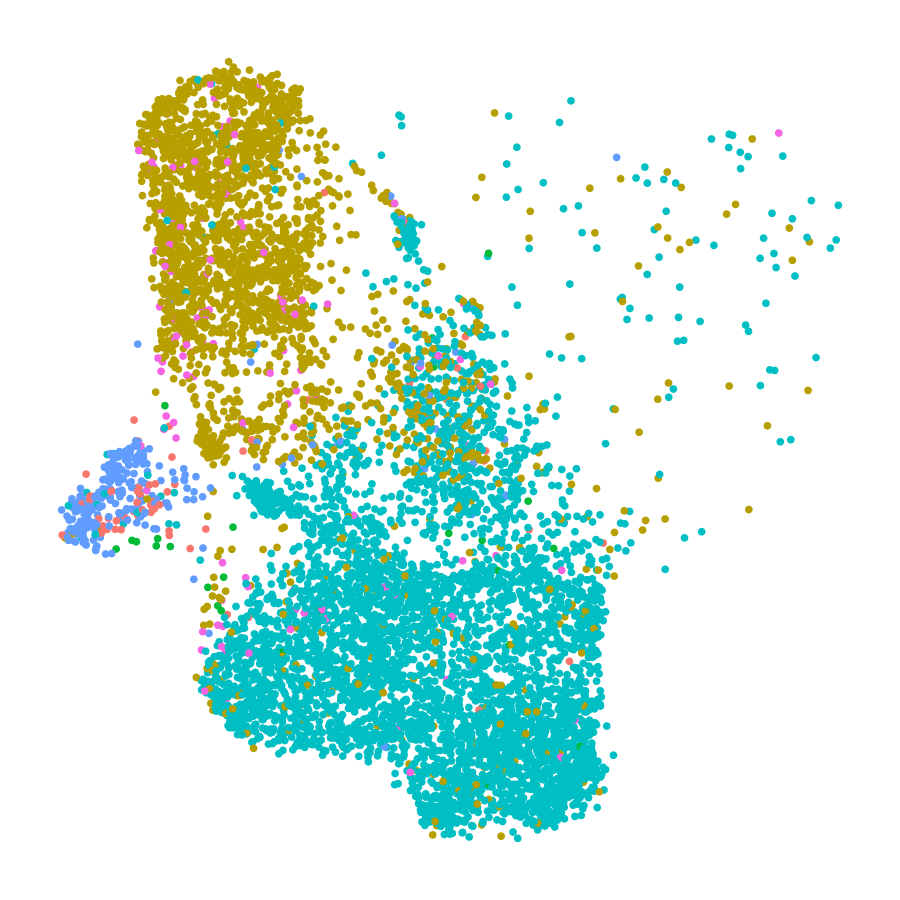

In [20]:
options(repr.plot.width =3, repr.plot.height = 3, repr.plot.res = 300)
DimPlot(Gal_KI36) + theme_void() + NoLegend()

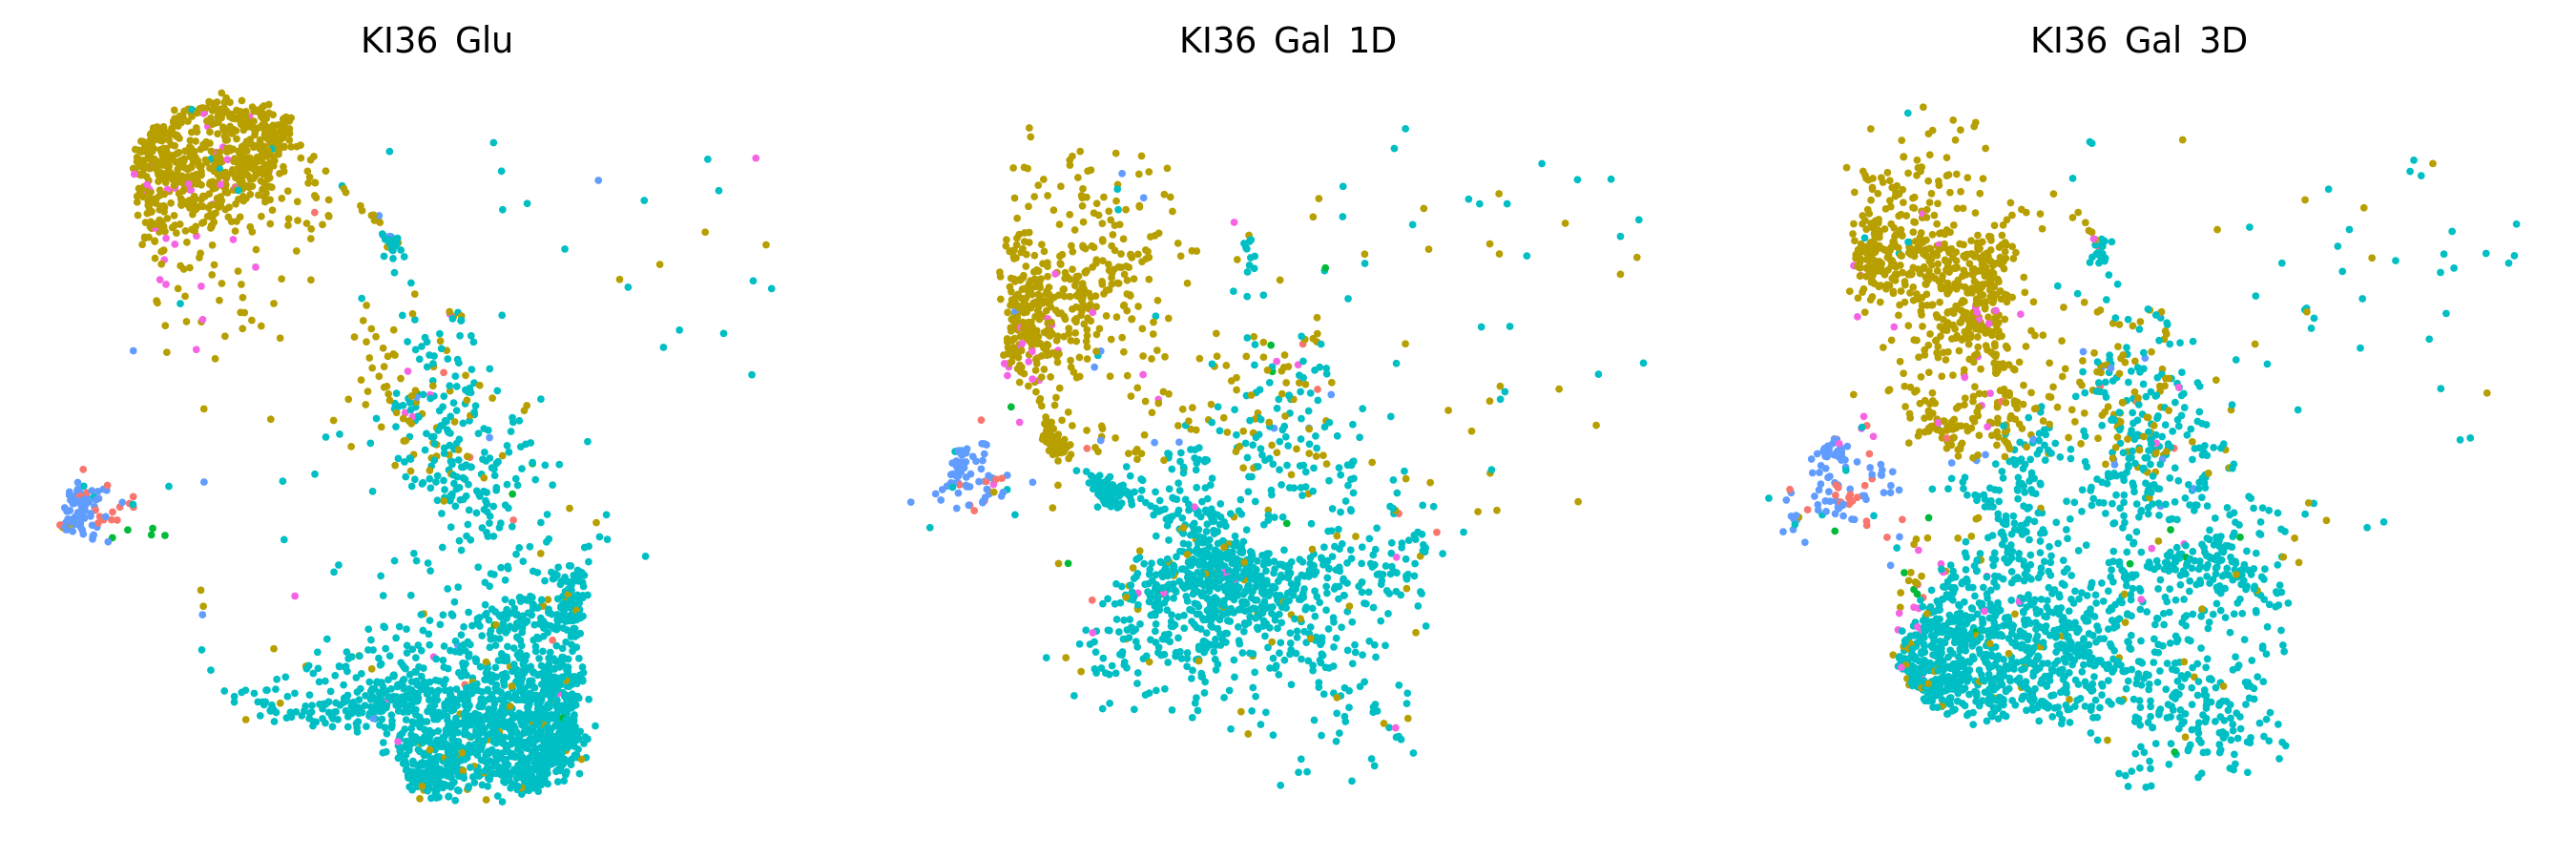

In [21]:
options(repr.plot.width =9, repr.plot.height = 3, repr.plot.res = 300)
DimPlot(Gal_KI36, split.by = "hash.ID") + theme_void() + NoLegend()

Scale for 'fill' is already present. Adding another scale for 'fill', which
will replace the existing scale.



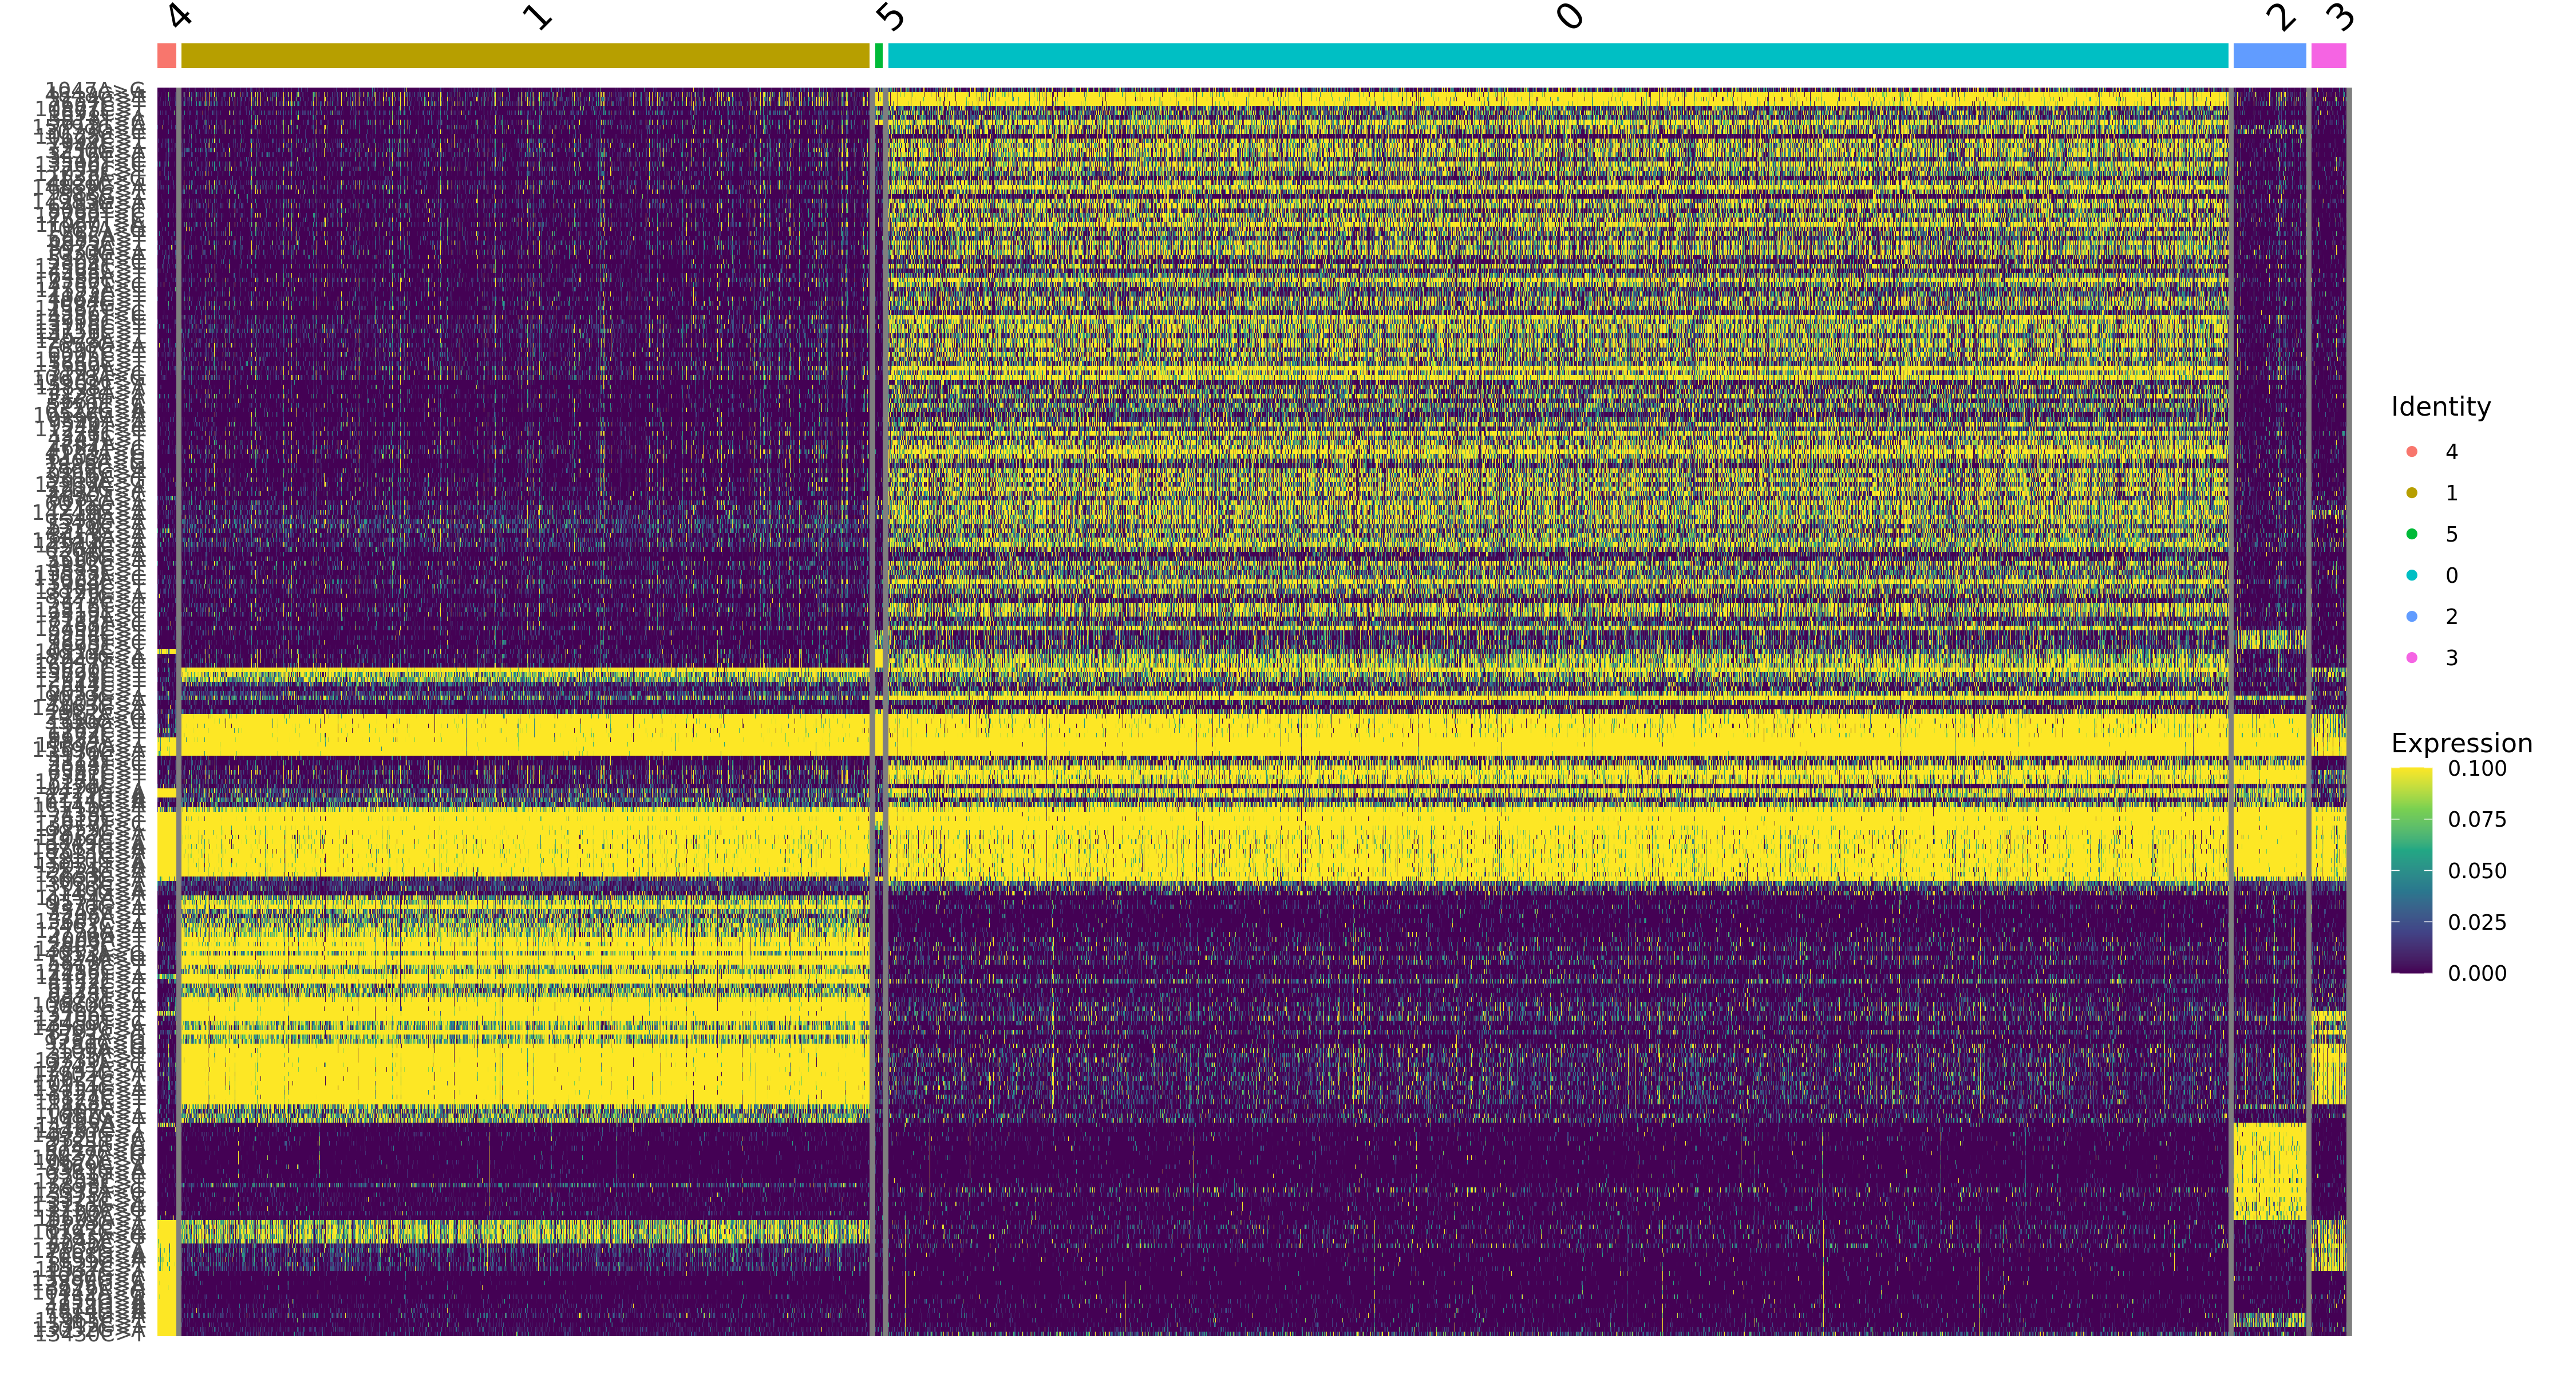

In [22]:
options(repr.plot.width =15, repr.plot.height = 8, repr.plot.res = 300)
DoHeatmap(Gal_KI36, features = VariableFeatures(Gal_KI36), slot = "data", disp.max = 0.1) +
  scale_fill_viridis_c()

In [23]:
variants_KI36 <- c("X15378T_C", "X13414G_A", "X10197G_A", "X8313G_A")
variant_names_KI36 <- c("m.15710C>T", "m.13414G>A", "m.10197G>A", "m.8313G>A")
VAF.long <- as.data.frame(Gal_KI36[["allele"]]@data) %>%
  rownames_to_column("variant") %>%
  separate(variant, into = c("Position", "Change"), sep = "(?<=\\d)(?=\\D)") %>%
  mutate(Position = as.numeric(Position)) %>%
  pivot_longer(cols = -c("Position", "Change"), names_to = "ID", values_to = "VAF")


In [24]:
md <- Gal_KI36@meta.data %>% rownames_to_column("ID") 

In [25]:
VAF.long <- inner_join(VAF.long, md[,c("ID","seurat_clusters", "hash.ID", "atacUMAP_1", "atacUMAP_2")], by = "ID" )


In [26]:
VAF.long <- VAF.long %>% mutate(present = VAF>0)

In [27]:
options(repr.plot.width =3, repr.plot.height = 3, repr.plot.res = 300)
plot_mtSNV <- function(pos, var){
  
  p1 <- VAF.long %>% filter(Position == pos & Change == var) %>% arrange(VAF) %>% 
    ggplot(aes(atacUMAP_1, atacUMAP_2, color=VAF)) + geom_point() + scale_color_viridis_c(limits = c(0, 1), breaks = seq(0,1,0.2)) +
    ggtitle(paste0(pos, var)) + theme_void() + NoLegend()
  
  #p2 <- VAF.long %>% filter(Position == pos & Change == var) %>% arrange(present) %>% 
  #  ggplot(aes(atacUMAP_1, atacUMAP_2, color=present)) + geom_point() + scale_color_manual(values = c("grey", "red")) + 
  #  theme_void() + ggtitle(paste0(pos, var))
  
  #p <- cowplot::plot_grid(p1, p2,ncol = 1)
  ggsave(plot = p1, paste0("../plot/subcluster_clonal_var",pos, gsub(">", "", var),".pdf"), width = 3, height=3)
  p1
}



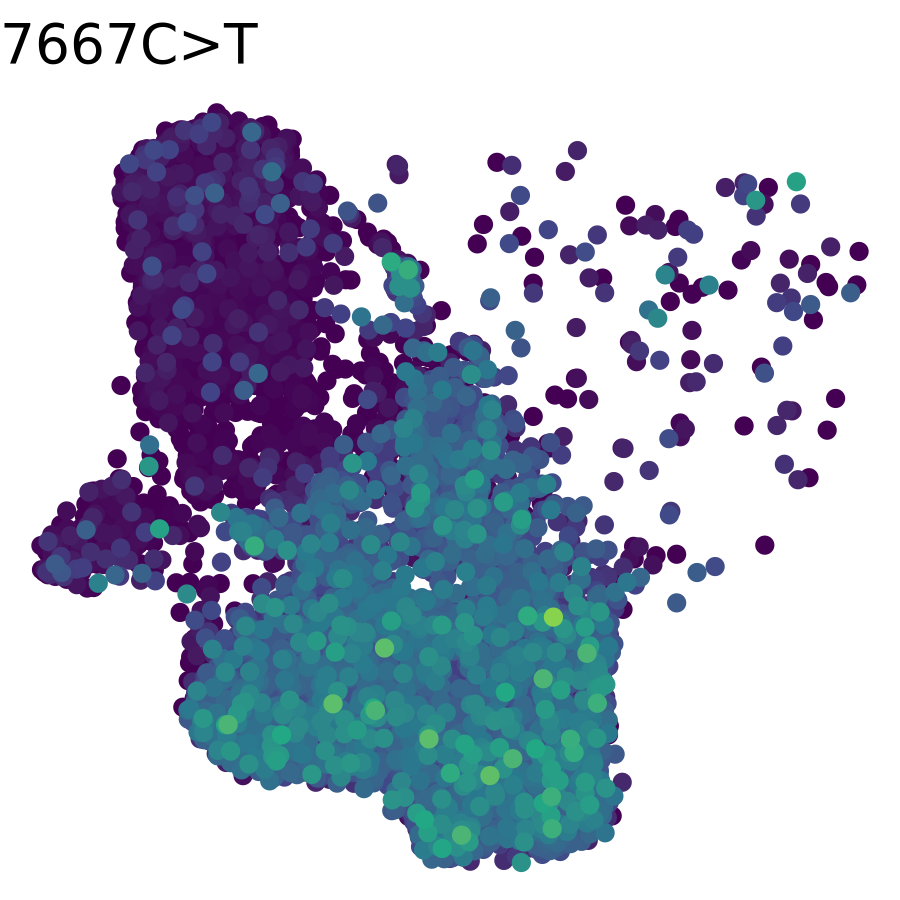

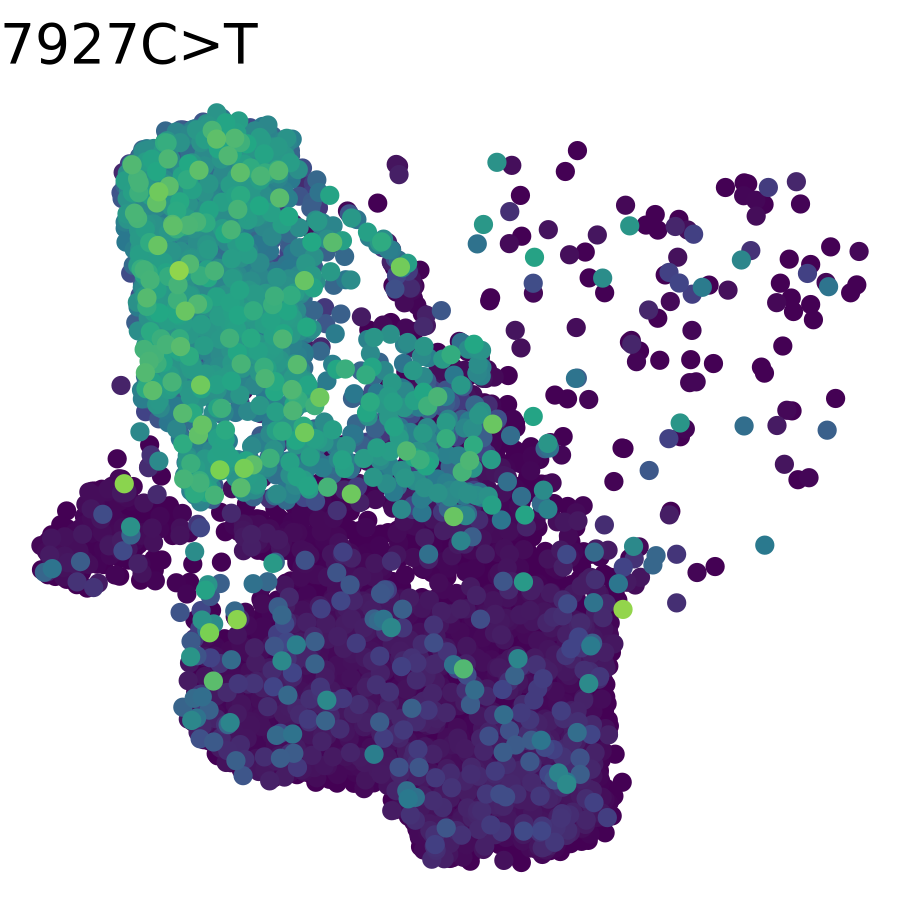

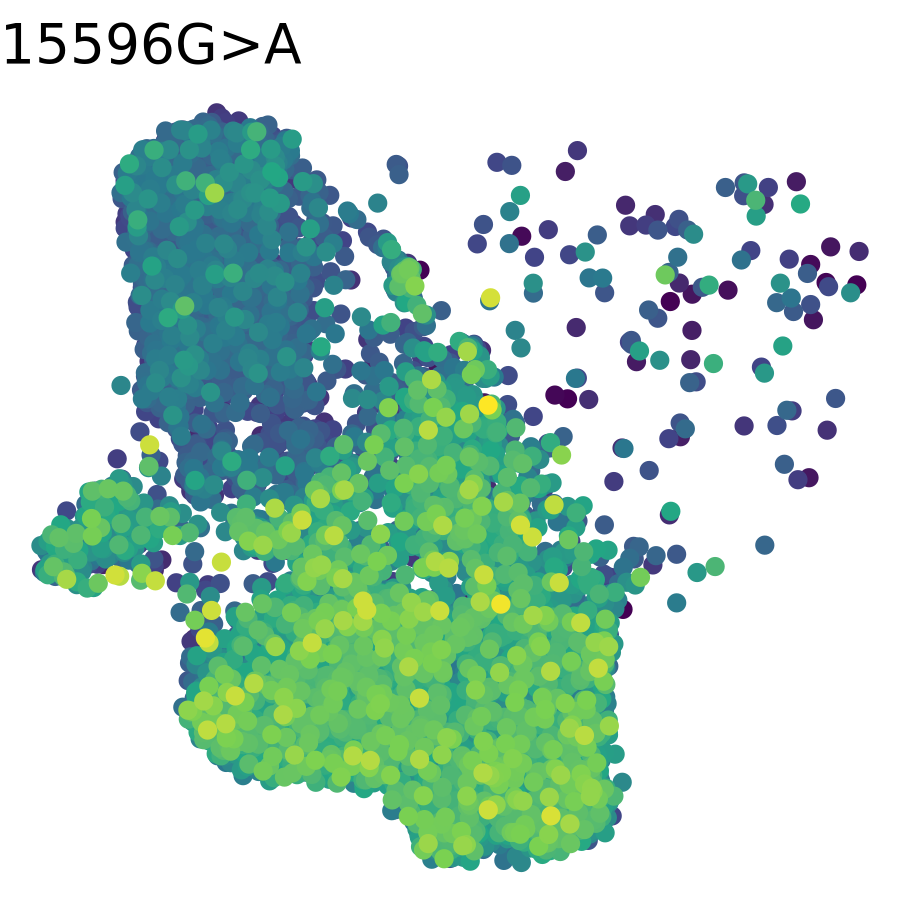

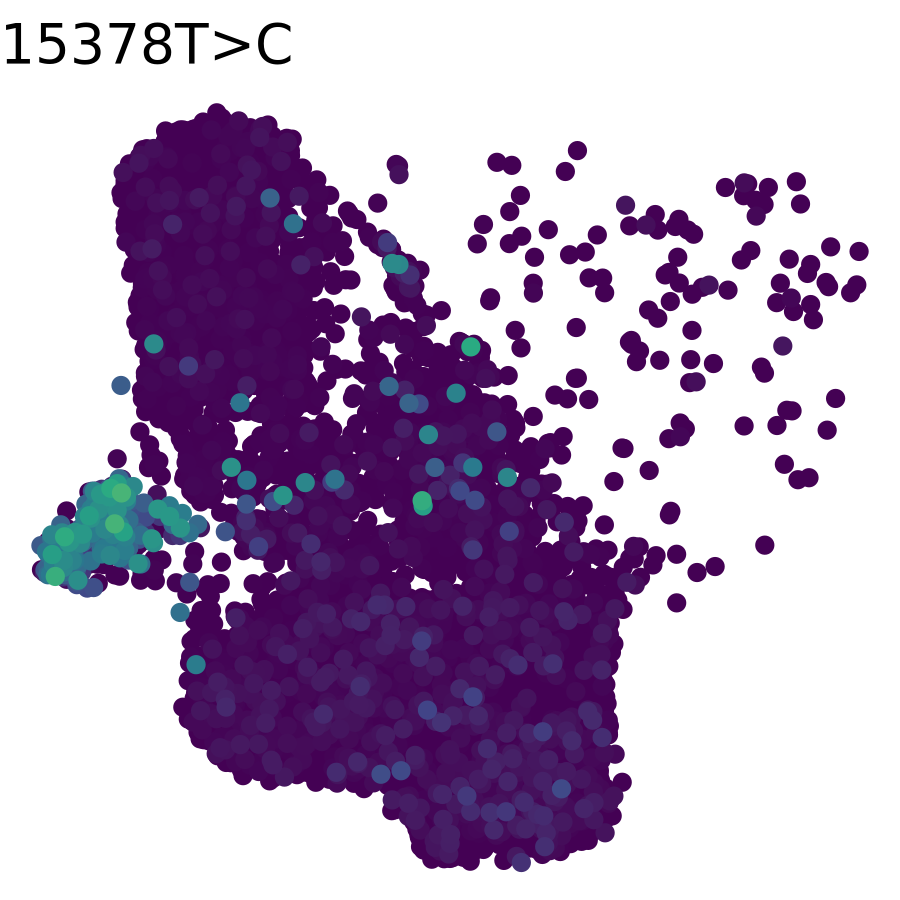

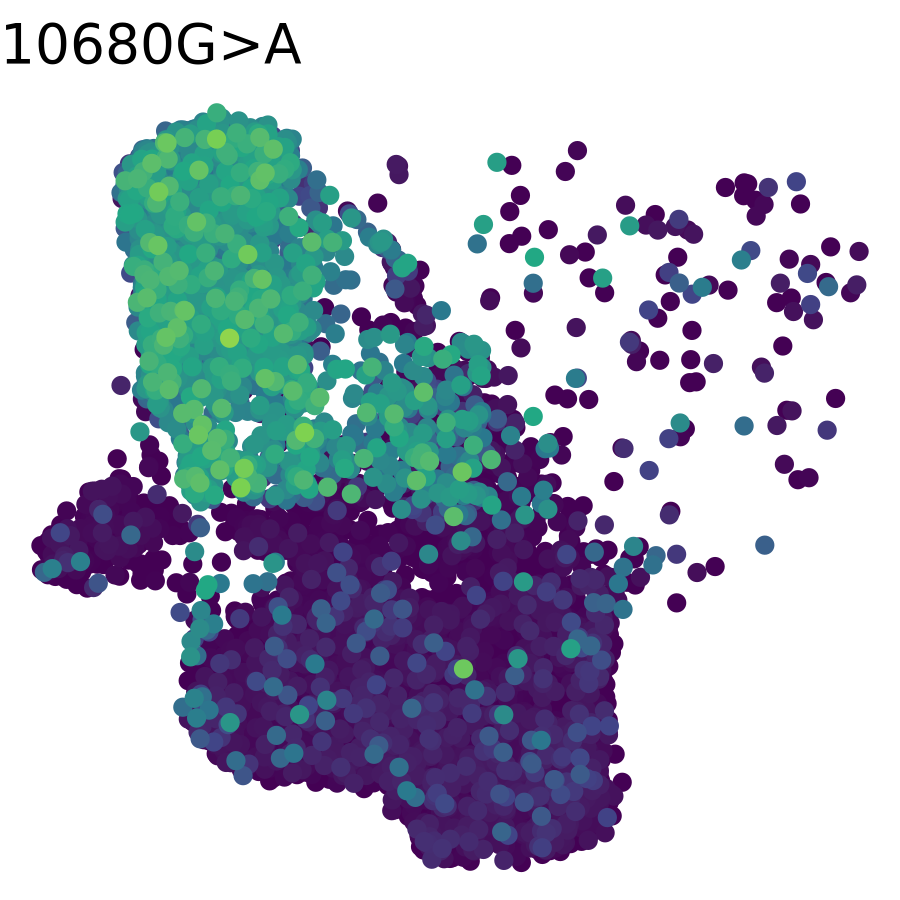

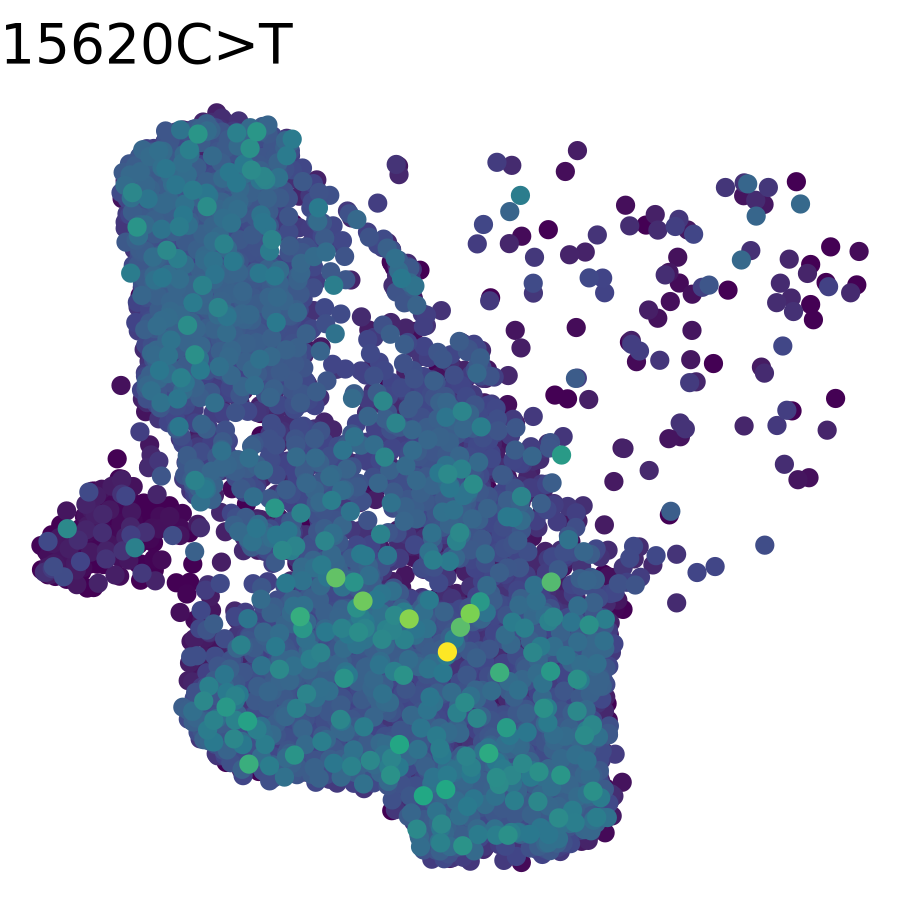

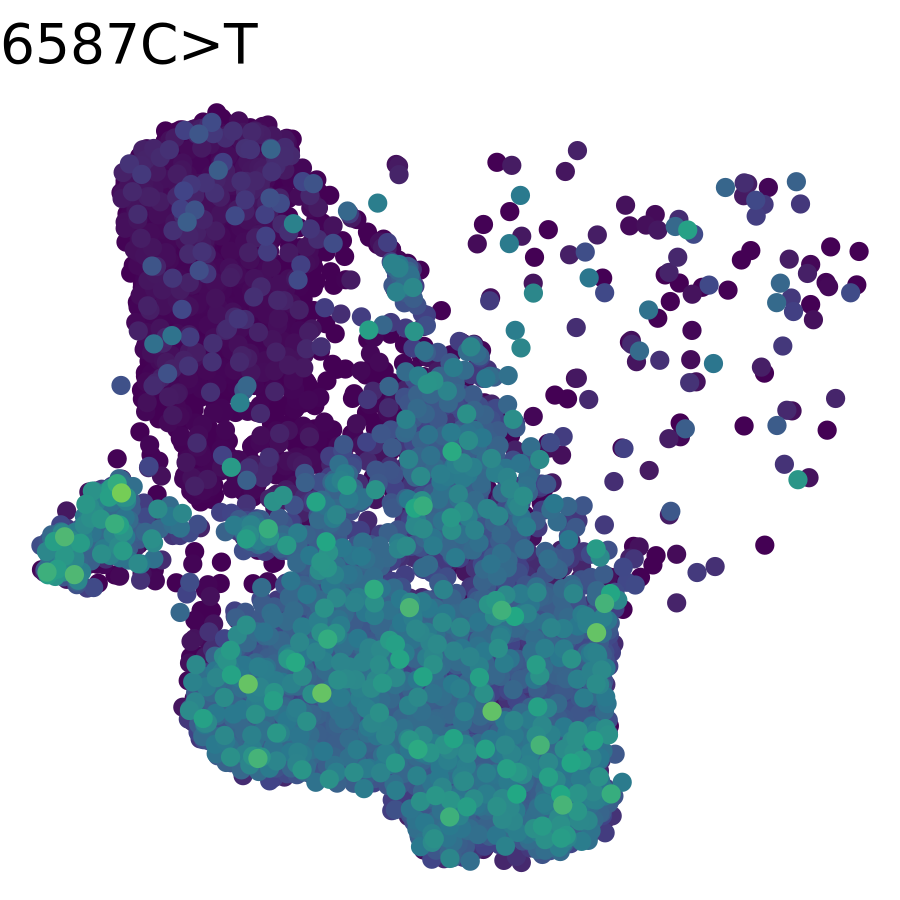

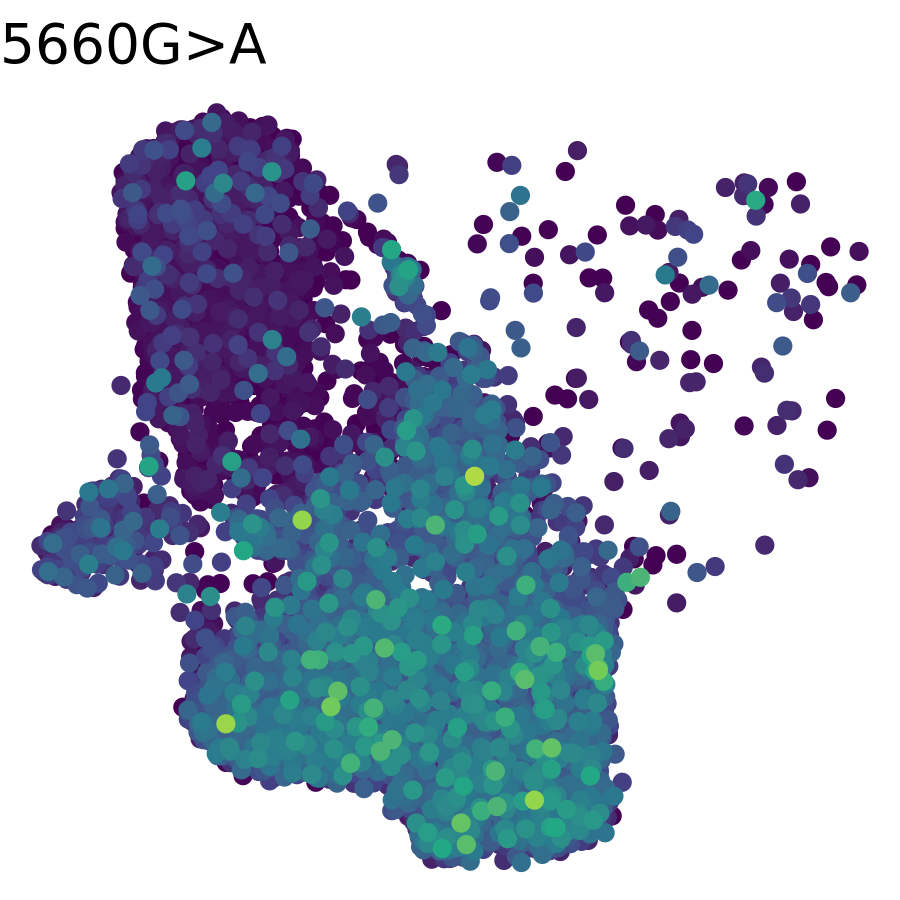

In [28]:
plot_mtSNV(7667, "C>T") # MT-CO2
plot_mtSNV(7927, "C>T") # MT-CO2
plot_mtSNV(15596, "G>A") # MT-CYB
plot_mtSNV(15378, "T>C") # MT-CYB
plot_mtSNV(10680, "G>A") # MT-ND4L
plot_mtSNV(15620, "C>T") # MT-ND4L
plot_mtSNV(6587, "C>T") # MT-CO2
plot_mtSNV(5660, "G>A") # MT-ND4L

In [29]:
head(Gal_KI36@meta.data)

,orig.ident,nCount_ATAC,nFeature_ATAC,total,duplicate,chimeric,unmapped,lowmapq,mitochondrial,nonprimary,⋯,MSS_weighted_CIII,MSS_weighted_CV,MSS_weighted_CIV,MSS_weighted_CI,MSS_weighted_rRNA,atacUMAP_1,atacUMAP_2,nCount_allele,nFeature_allele,allele_snn_res.0.02
,<chr>,<dbl>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
rep1_AAACGAAAGAGCAGCT-1,SeuratProject,35537,25427,256580,rep1,139,818,15411,74210,188,⋯,0.2254938,0.05497263,1.704729,3.668505,1.0383528,-5.295811773,-1.142920,17.48402,106,4
rep1_AAACGAAAGCATGATA-1,SeuratProject,26944,19229,156082,rep1,52,362,12441,22475,173,⋯,0.4360035,0.07724425,2.170679,3.328067,1.1488435,0.004153371,-3.380790,20.50947,174,0
rep1_AAACGAACAACGCACC-1,SeuratProject,21136,15556,231741,rep1,171,741,9443,114527,71,⋯,0.1883547,0.03813738,1.254807,2.024761,0.9076724,-2.478328109,1.435028,21.48934,144,1
rep1_AAACGAAGTTGCTTGA-1,SeuratProject,6441,5367,140029,rep1,178,811,6124,69334,88,⋯,0.3672724,0.03465761,1.675659,3.206938,1.3554302,0.447388529,-1.140828,24.23608,180,0
rep1_AAACTCGAGAACCATA-1,SeuratProject,15782,13346,81672,rep1,28,192,6191,7459,150,⋯,0.2720782,0.05892543,1.117541,2.833291,1.0545137,1.693551659,-1.788584,23.69183,154,0
rep1_AAACTCGAGGACTTTC-1,SeuratProject,22360,16569,141409,rep1,82,439,7870,39744,70,⋯,0.1895914,0.03962063,1.089863,2.610364,1.0223528,-3.008744240,1.932703,20.96285,127,1


In [31]:
df <- Gal_KI36@meta.data
rownames(df) <- sub(pattern = "_", replacement = "#", rownames(df))

In [32]:
write.csv(df, "../output/Gal_KI36_meta.csv", quote = FALSE, row.names = TRUE)